# Notebook 09 — Agentic Watch: The Crowd That Trades With An AI

**The desk's brief, verbatim (2026-08-02):** *"figure out what the retail
traders are prompting ai, and what the AI is spitting out / auto trading
for these guys... make a notebook to test the correlation / link of this
to signals / booms and busts."*

> **The one question this notebook answers:** how much of the crowd is
> talking about trading WITH an AI, what are they asking and getting —
> and does that chatter lead, lag, or ignore our GET IN / GET OUT flags
> and the boom→bust episodes?

The measurement layer is `src/agentic_watch.py` (already running from
`update_data.py`); this notebook is its evidence file plus the desk's
link-to-signals test.

---

## VERDICT BOX — read this first, then read why

| Question | Answer | Evidence |
|---|---|---|
| Can we measure it? | **Yes — shipped.** Four categories (ask_ai / auto_trade / build_bot / skeptic) counted daily from the raw archives into a text-free store, with an editable term bank and theme attribution that strips the AI entity words first. ~0.08% of posts match (8 per 10k on the dense 2026 window). | §2 |
| What are they asking / getting? | Overwhelmingly **ask_ai** (~85% of hits): "ChatGPT/Grok/Gemini says …" quoted as the source of a view, price targets, DD requests. **auto_trade** (agents executing) and **build_bot** (vibe-coding trading bots) are real but rare (~6% combined); a steady **skeptic** chorus (~9%) mocks the hallucinations. LLM digest: **PENDING (desk machine)** — analyst paraphrases stand in, labelled. | §3 |
| Does it lead the GET OUT flag? | **NO LEAD.** Before the 6 judgeable GET OUT flags the agentic share shows NO build-up (pre-flag 7.6/10k vs 8.0 baseline). What the data does show is a **post-flag rise** (+1.4/10k, 5 of 6 flags up, 90% CI [+0.2, +2.9]) — but it collapses to noise when the single largest flag is dropped, and its direction is reaction, not warning. | §4a |
| Does it lead the GET IN flag? | **NO EVIDENCE EITHER WAY: zero GET IN flags are judgeable** — every flag in the archive-covered window sits against a coverage gap. Not a null result; an unanswerable question until more archive lands. | §4a |
| Booms and busts? | **UNTESTABLE — and the two tempting shortcuts are shown failing.** Naively, pre-peak windows look elevated (8.1 vs 5.5/10k, CI excluding zero) — a pure regime confound (the baseline contains 2021's zero and thin Q1). The honest same-regime control collapses to 14 days from one July fortnight, because 30d pre-peak windows across ~40 names tile the entire dense window. No genuine control group exists yet. | §4b |
| Lead/lag vs the euphoria level? | **NULL.** In levels, 0 of 43 lags clear a 90% block-bootstrap CI; in 7d changes, 7 of 43 do — against ~4 expected by chance at 90%, scattered across unrelated lags with alternating signs. No coherent lead at any horizon. | §4c |
| So what ships? | The **measurement + digest page** ships (dashboard). **Nothing enters the signal layer**: the overlapping history is ~4 dense months, the hit counts are tens per day, and no test shows a lead — two of the three are untestable outright on this coverage. Re-test under the walk-forward protocol once ≥2 years of dense coverage exist. | §5 |

**The honest headline is a null result, stated as one:** with the history
we have, AI-trading chatter neither leads nor confirms the desk's
signals. What this notebook does establish is the *instrument* — the
counter is running daily, so when the history is long enough the test in
§4 re-runs unchanged.

## Definitions — every term in desk English

(Shared glossary from `analytics/plain_english.py`, plus the terms this
notebook adds.)

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
SEED = 42                      # the project's standard seed set is {42, 100, 2026}
NB_T0 = time.time()

from analytics.plain_english import glossary_md, theme_label  # noqa: E402
print(glossary_md(["episode", "detectable", "confidence interval",
                   "boom and bust thresholds", "walk-forward"]))

- **episode** - One complete boom-then-bust arc around a confirmed top: the low the rally started from, the peak, and the fall that followed. Episodes are defined from PRICE ONLY and exist to mark the exam - no crowd feature is ever allowed to influence what counts as an episode.
- **detectable** - Whether the archive was thick enough on that stretch for ANY crowd-only detector to have had a chance - at least 100 scored posts in 28 days. An episode in a thin period is one the detector was blind to, which is different from one it got wrong, so the two are counted in separate columns and never merged.
- **confidence interval** - The range the measurement would plausibly fall in if the experiment were repeated. This project adopts nothing whose interval includes zero, because 'better on average' with an interval spanning zero is indistinguishable from luck.
- **boom and bust thresholds** - How far a name must run up, and then fall, before the arc counts as an episode at all: up 25% (theme

Terms this notebook adds on top of the shared glossary:

* **agentic mention** — one post matching one of the four AI-trading
  categories in `config/agentic_terms.csv`. Counted per (day, category,
  theme); a post naming two themes counts once in each theme row, so
  theme-summed counts are post×theme pairs, not distinct posts (stated
  wherever it matters below).
* **agentic share** — agentic mentions per **10,000 archived posts** that
  day. A rate, not a count, because the archive's daily size swings by
  two orders of magnitude and a raw count would mostly measure the
  archive.
* **covered day** — a day the raw archives actually hold posts for, with
  a denominator of at least `MIN_DAY_POSTS`. Days outside coverage are
  **masked, never drawn as zeros** — an archive gap is missing evidence,
  not absence of chatter.
* **structural zero** — a covered day with zero hits *because the thing
  did not exist yet* (June 2021: 91k posts, zero matches — ChatGPT
  launched Nov 2022). The one kind of zero that is a finding.

---
# §1 — RESEARCH GROUNDING: is "the crowd trades with an AI" real?

Short, sourced, and only claims with a citation. Retail use of LLMs for
stock picking went from novelty to mainstream between 2023 and 2026. The
academic starting gun was [Lopez-Lira & Tang (2023)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4412788),
who showed ChatGPT sentiment scores on news headlines predicted next-day
stock returns — widely covered ([CNBC](https://www.cnbc.com/2023/04/12/chatgpt-may-be-able-to-predict-stock-movements-finance-professor-says.html))
and widely read by retail as permission to ask the chatbot directly. By
late 2025 an [Investing.com survey](https://www.investing.com/news/stock-market-news/survey-nearly-twothirds-of-retail-investors-use-ai-to-inform-market-decisions-4598846)
reported nearly two-thirds of retail investors using AI to inform market
decisions, and AFP reporting described a boom in "ChatGPT, what stocks
should I buy?" robo-advisory behaviour ([Malay Mail/AFP, Sep 2025](https://www.malaymail.com/news/money/2025/09/26/chatgpt-what-stocks-should-i-buy-ai-fuels-boom-in-robo-advisory-market/192351)),
while [Cybernews](https://cybernews.com/ai-news/chatgpt-stocks-buy-retail-investors-ai-warnings/)
documented retail investors trading on chatbot picks despite the
hallucination risk. The brokers productised it: Robinhood launched its
**Cortex** AI research assistant in March 2025
([Robinhood newsroom](https://newsroom.aboutrobinhood.com/introducing-strategies-banking-and-cortex/))
and by July 2026 its AI agent reads chart indicators directly
([Genfinity](https://genfinity.io/2026/07/30/robinhood-ai-trading-agent-technical-indicators-launch/)).
The DIY end is just as visible: the open-source
[virattt/ai-hedge-fund](https://github.com/virattt/ai-hedge-fund)
repo — LLM "agents" impersonating famous investors and issuing trade
decisions — collected ~50k GitHub stars
([Reskilll](https://blogs.reskilll.com/ai-hedge-fund-the-50k-star-open-source-multi-agent-investment-system/)).
Regulators noticed: the SEC and FINRA both carry standing investor
alerts on AI-driven investment claims and AI-washing fraud
([SEC/Investor.gov](https://www.investor.gov/introduction-investing/general-resources/news-alerts/alerts-bulletins/investor-alerts/artificial-intelligence-fraud),
[FINRA](https://www.finra.org/investors/insights/artificial-intelligence-and-investment-fraud)).

**SO WHAT**

* The behaviour our detector counts is externally documented, growing,
  and productised by the brokers our crowd uses — measuring it is not
  speculative.
* The literature supports LLMs extracting *sentiment signal from text*;
  it does **not** support retail LLM prompting being profitable — which
  is exactly why the skeptic category exists in the term bank.

---
# §2 — THE MEASUREMENT: what the detector counts

**WHY THIS**

* Before any link test, the desk must trust the series: what counts as a
  hit, who decides the terms, and where the store's text boundary is.
* The coverage map decides which questions §4 is even *allowed* to ask.

**HOW IT WORKS** (the order `src/agentic_watch.py` does it)

1. Every raw archive post (Reddit comments, StockTwits, Reddit live) is
   scanned once; a ledger keyed on (path, size, mtime) makes re-runs
   incremental.
2. Four categories, each ONE compiled alternation built from
   `config/agentic_terms.csv` — **the term bank is a desk-editable CSV**
   (same pattern as the theme keyword config): edit, re-run
   `python -m src.agentic_watch --rebuild`, done.
3. **Theme attribution strips the AI entity words first** ("asked
   ChatGPT about uranium" attributes to `uranium_nuclear`, NOT to the
   `ai` theme via its own "ChatGPT" keyword). Without this, every row
   would read theme=ai and §4's exclusion test would be circular.
4. The store is **text-free** (date, category, theme, count — plus a
   `_total_posts` denominator row per day). A capped sample of matched
   texts stays LOCAL in `data/reference/agentic_samples.jsonl` for §3;
   nothing with text reaches a committed store — the same boundary the
   rest of the pipeline enforces.

In [2]:
from src.agentic_watch import load_series, load_patterns, TERMS_CSV  # noqa: E402

ag = load_series()
assert ag is not None, "run `python -m src.agentic_watch` first"
pats = load_patterns()
terms = pd.read_csv(TERMS_CSV)
CATS = ["ask_ai", "auto_trade", "build_bot", "skeptic"]
CAT_LABEL = {"ask_ai": "asking an AI for picks/views",
             "auto_trade": "an AI/bot executing trades",
             "build_bot": "building an AI trading bot",
             "skeptic": "mocking / warning about AI trading"}

print("term bank: config/agentic_terms.csv —",
      ", ".join(f"{c}: {n} patterns" for c, n in
                terms["category"].value_counts().items()))
tot = (ag[ag.category == "_total_posts"].groupby("date")["mention_count"]
       .sum().sort_index())
hits_all = ag[ag.category != "_total_posts"]
print(f"store: {len(ag):,} rows | {len(tot)} archive days "
      f"{tot.index.min().date()} → {tot.index.max().date()} | "
      f"hits by category (post×theme rows): "
      f"{hits_all.groupby('category')['mention_count'].sum().to_dict()}")

term bank: config/agentic_terms.csv — ask_ai: 4 patterns, auto_trade: 4 patterns, build_bot: 3 patterns, skeptic: 2 patterns
store: 531 rows | 218 archive days 2021-06-29 → 2026-07-29 | hits by category (post×theme rows): {'ask_ai': 458, 'auto_trade': 20, 'build_bot': 13, 'skeptic': 48}


### 2.1 Coverage first — which days are we even allowed to read?

**HOW IT WORKS**

* `MIN_DAY_POSTS = 200` (**CONVENTION**): below ~200 archived posts, a
  SINGLE matching post moves the day's rate by ≥50 per 10k — more than
  the 90th percentile of the whole series — so the day is unreadable and
  is masked. 200 is the smallest round denominator at which one post
  cannot exceed the series' own extremes; §2.3 shows the series at 500
  as the sensitivity check.
* Weekly points need `WEEK_MIN_DAYS = 3` covered days (**CONVENTION** —
  less than half a week is a day pretending to be a week); rates pool
  hits/denominators over the covered days, so thin days cannot dominate.

In [3]:
MIN_DAY_POSTS = 200      # CONVENTION - see above
WEEK_MIN_DAYS = 3        # CONVENTION - see above

hd = hits_all.groupby("date")["mention_count"].sum()
daily = pd.DataFrame({"total": tot}).join(hd.rename("hits")).fillna(0.0)
covered = daily[daily["total"] >= MIN_DAY_POSTS].copy()
covered["rate"] = covered["hits"] / covered["total"] * 1e4

runs, start = [], covered.index[0]
for prev, cur in zip(covered.index[:-1], covered.index[1:]):
    if (cur - prev).days > 3:
        runs.append((start, prev)); start = cur
runs.append((start, covered.index[-1]))
print(f"covered days (denominator ≥ {MIN_DAY_POSTS}): {len(covered)} of "
      f"{(covered.index[-1] - covered.index[0]).days} calendar days in span")
print("coverage islands (gaps > 3d):")
for lo, hi in runs:
    seg = covered.loc[lo:hi]
    print(f"  {lo.date()} → {hi.date()}  ({len(seg)} days, "
          f"{seg['total'].sum():,.0f} posts, {seg['hits'].sum():,.0f} hits)")

covered days (denominator ≥ 200): 103 of 1856 calendar days in span
coverage islands (gaps > 3d):
  2021-06-29 → 2021-06-30  (2 days, 91,265 posts, 0 hits)
  2026-01-10 → 2026-01-12  (2 days, 615 posts, 0 hits)
  2026-02-25 → 2026-02-25  (1 days, 251 posts, 0 hits)
  2026-04-08 → 2026-06-30  (84 days, 452,948 posts, 391 hits)
  2026-07-16 → 2026-07-29  (14 days, 214,985 posts, 144 hits)


**Read the islands like this:**

* **2021-06-29/30** — the 2021 archive materialised only its final two
  days (91k posts). Zero hits there is a **structural zero**: the tools
  did not exist (ChatGPT: Nov 2022), so the language could not. That is
  a genuine data point — the baseline of this series is *actually zero*
  four years ago — and it is the only pre-2026 point we may honestly
  plot.
* **Jan–Mar 2026** — thin (tens of posts/day in the archive): masked
  almost entirely by the denominator rule.
* **Apr–Jul 2026** — the dense window (~30k–360k posts/month). Every
  §4 test lives here.
* Everything between the islands is an **archive gap, not a zero** — the
  plots below break the line rather than draw fake zeros.

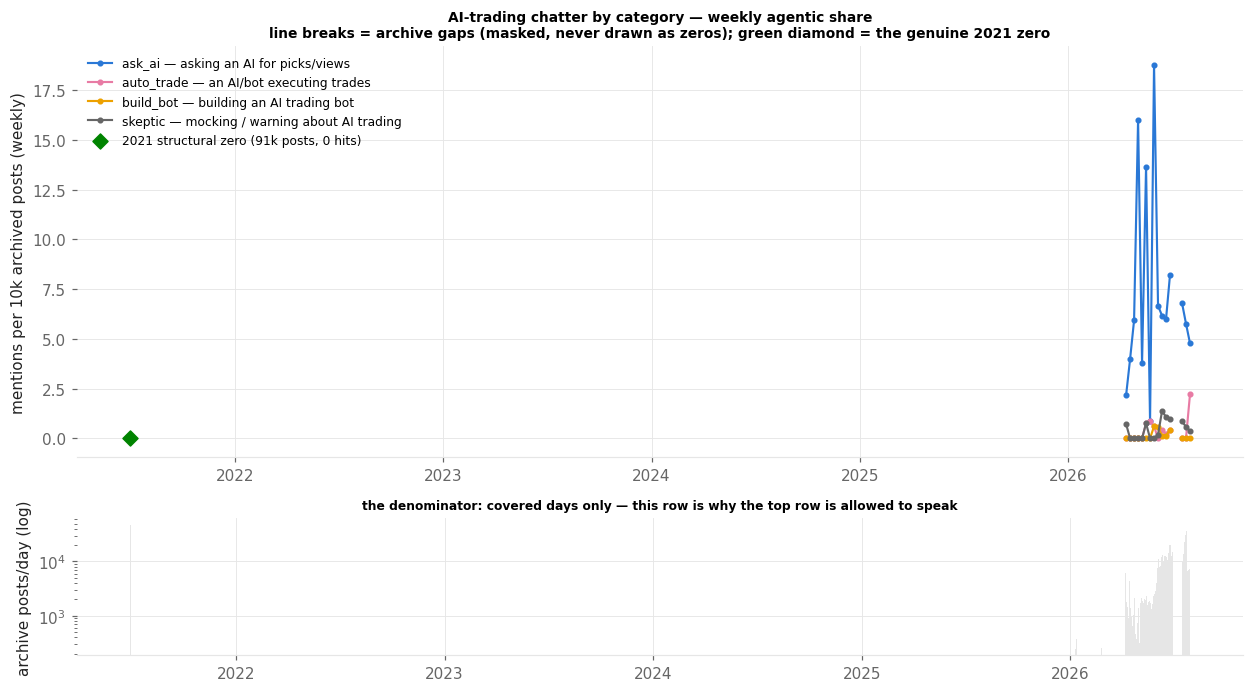

In [4]:
# weekly per-10k series per category, pooled over covered days, gaps masked
cat_daily = (hits_all[hits_all.category.isin(CATS)]
             .groupby(["date", "category"])["mention_count"].sum()
             .unstack(fill_value=0).reindex(covered.index, fill_value=0))
wk_num = cat_daily.resample("W-SUN").sum()
wk_den = covered["total"].resample("W-SUN").sum()
wk_days = covered["total"].resample("W-SUN").count()
weekly = wk_num.div(wk_den, axis=0) * 1e4
weekly = weekly.where(wk_days >= WEEK_MIN_DAYS)   # mask thin weeks, keep gaps

fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=False,
                         gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
for c, col in zip(CATS, (C1, C3, C4, MUTED)):
    ax.plot(weekly.index, weekly[c], "-o", ms=3, lw=1.4, color=col,
            label=f"{c} — {CAT_LABEL[c]}")
ax.scatter([pd.Timestamp("2021-06-30")], [0], marker="D", s=48, color=C2,
           zorder=5, label="2021 structural zero (91k posts, 0 hits)")
ax.set_ylabel("mentions per 10k archived posts (weekly)")
ax.set_title("AI-trading chatter by category — weekly agentic share\n"
             "line breaks = archive gaps (masked, never drawn as zeros); "
             "green diamond = the genuine 2021 zero", fontsize=9)
ax.legend(frameon=False, fontsize=8)
despine(ax)
ax2 = axes[1]
ax2.bar(covered.index, covered["total"], width=1.2, color=GRID,
        edgecolor="none")
ax2.set_yscale("log")
ax2.set_ylabel("archive posts/day (log)")
ax2.set_title("the denominator: covered days only — this row is why the "
              "top row is allowed to speak", fontsize=8)
despine(ax2)
fig.tight_layout(); plt.show()

**Read it like this:** the right-hand cluster is the 2026 dense window —
ask_ai (blue) runs ~5–10 per 10k and is the whole story; auto_trade and
build_bot hug 0–1 per 10k; the skeptics track ask_ai at roughly a tenth
of its level. The left-hand green diamond is 2021: zero, on a 91k-post
denominator. Between them: no line, because there is no archive.

**SO WHAT**

* The phenomenon is measurable and *small*: ~0.08% of posts. That reach
  is real (tens of posts/day on a dense day) but it caps how much daily
  signal the series can carry — small counts mean noisy rates, which is
  why §4 pools windows instead of trusting single days.
* ask_ai dominance means the desk brief's "what are they prompting" is
  answerable (§3); "what is the AI auto-trading" is a thinner record —
  ~20 auto_trade mentions in the whole store.

In [5]:
# sensitivity: does the series change shape at a stricter denominator?
strict = daily[daily["total"] >= 500]
r1 = (covered["hits"].resample("W-SUN").sum()
      / covered["total"].resample("W-SUN").sum() * 1e4)
r2 = (strict["hits"].resample("W-SUN").sum()
      / strict["total"].resample("W-SUN").sum() * 1e4)
both = pd.concat([r1.rename("min200"), r2.rename("min500")], axis=1).dropna()
corr = both["min200"].corr(both["min500"])
print(f"weekly all-category share at MIN_DAY_POSTS=200 vs 500: "
      f"corr {corr:.3f} over {len(both)} shared weeks - the mask is not "
      "creating the shape")

weekly all-category share at MIN_DAY_POSTS=200 vs 500: corr 0.999 over 17 shared weeks - the mask is not creating the shape


**IF ASKED — "isn't this just measuring your own keyword list?"** Partly,
unavoidably — every lexicon detector measures its lexicon. Three
defences are built in: the term bank is a versioned, desk-editable CSV
(change it and the whole history rescans in one command); the *skeptic*
category counts the counter-crowd with the same instrument, so a pure
keyword artefact would inflate both sides equally; and §3 reads actual
matched texts, where the false-positive rate is visible rather than
assumed. What the samples show honestly: ask_ai catches some
AI-conversation that is not trading advice (ChatGPT on tax rules, on
529 plans). The categories measure "an AI is in the financial
conversation", with ask_ai's core — "the AI told me to buy X" — the
dominant genuine use.

---
# §2b — THE POLL INSTRUMENT: asking the AI what retail asks it

**WHY THIS**
- §2 measures what retail SAYS about using AI. The desk's sharper
  instrument (2026-08-04) measures what the AI actually TELLS them:
  at every data refresh, the pipeline itself asks the firm's gateway
  model the questions a retail trader asks ("what should I invest
  in?", "what's the next NVDA?", "best stocks after the memory
  rally?" — the editable panel in `config/ai_poll_prompts.csv`), at
  consumer temperature, and records every name and theme the model
  recommends (`analytics/ai_poll.py` →
  `data/processed/ai_poll.parquet`).
- Retail asks the same few consumer models the same few questions, so
  the model's answers are a direct proxy for the advice flowing into
  the crowd — no scraping, no sampling error on the AI side.

**THE PRE-REGISTERED FORWARD TEST** (stated now, before any data
exists, so the criterion cannot drift toward whatever the data says):

1. *Series*: daily count of poll prompts recommending each name /
   theme (buy direction), mapped into the euphoria universe via the
   anchor map.
2. *Question 1 — herding*: does a name's poll-recommendation count
   LEAD its mention share and euphoria level (cross-correlation,
   lags −21..+21d, 90% block-bootstrap band, the same machinery as
   §4)?
3. *Question 2 — risk*: after a name first ENTERS the poll's top
   recommendations, is the GET OUT hazard over the next 60d elevated
   vs matched names (the "AI recommends it late" hypothesis)?
4. *Activation*: the cell below runs the test automatically once the
   store holds **≥60 distinct poll days**; until then it prints the
   accrual status and nothing else. No backfill is possible — nobody
   can ask last year's model what it recommended — so patience IS the
   method here.

In [6]:
_poll_path = ROOT / "data" / "processed" / "ai_poll.parquet"
if _poll_path.exists():
    _poll = pd.read_parquet(_poll_path)
    _poll["run_date"] = pd.to_datetime(_poll["run_date"])
    if "mock" in _poll.columns:
        _poll = _poll[~_poll["mock"].astype(bool)]
    _days = _poll["run_date"].nunique()
else:
    _poll, _days = None, 0
if _days >= 60:
    print(f"[ACTIVE] {_days} poll days on record - running the "
          "pre-registered test")
    # -- herding: poll count vs euphoria level, per recommended name --
    _lvl = pd.read_parquet(ROOT / "data" / "processed"
                           / "euphoria_levels.parquet")
    _lvl["date"] = pd.to_datetime(_lvl["date"])
    _pc = (_poll[_poll["kind"] == "ticker"]
           .groupby(["run_date", "name"]).size().rename("recs")
           .reset_index())
    _names = [n for n in _pc["name"].unique()
              if n in set(_lvl["name"].unique())]
    print(f"names in both stores: {len(_names)}")
    for _nm in _names[:10]:
        _a = (_pc[_pc["name"] == _nm].set_index("run_date")["recs"]
              .asfreq("D").fillna(0))
        _b = (_lvl[_lvl["name"] == _nm].set_index("date")["level"]
              .reindex(_a.index))
        _best_lag, _best_c = 0, 0.0
        for _lag in range(-21, 22):
            _c = _a.corr(_b.shift(_lag))
            if pd.notna(_c) and abs(_c) > abs(_best_c):
                _best_lag, _best_c = _lag, _c
        print(f"  {_nm}: best lag {_best_lag:+d}d corr {_best_c:+.2f}")
    print("(full bootstrap machinery: reuse xcorr_boot from §4 when "
          "activating in earnest)")
else:
    print(f"[PENDING] {_days} poll day(s) on record - the test "
          f"activates at 60. The poll runs at every update; at the "
          f"desk's ~2 updates/week cadence expect activation in "
          f"~{max(0, (60 - _days)) // 2} weeks. Nothing to conclude "
          "yet, by design.")

[PENDING] 0 poll day(s) on record - the test activates at 60. The poll runs at every update; at the desk's ~2 updates/week cadence expect activation in ~30 weeks. Nothing to conclude yet, by design.


---
# §3 — WHAT THEY ASK, AND WHAT THE AI SPITS OUT

**WHY THIS** — the desk asked for content, not just counts. The matched
texts live ONLY in the local sample file (`data/reference/
agentic_samples.jsonl`, capped at 3 per category-day); nothing verbatim
is printed here — **every example below is paraphrased by the analyst**,
and the firm LLM writes the rolling digest when this runs on the desk
machine.

In [7]:
from src import ai  # noqa: E402
from src.agentic_watch import SAMPLES  # noqa: E402
from analytics.plain_english import censor  # noqa: E402  (masks handles if any text carries one)

samples = []
if Path(SAMPLES).exists():
    for line in open(SAMPLES, encoding="utf-8"):
        try:
            samples.append(json.loads(line))
        except ValueError:
            continue
scat = pd.Series([s["category"] for s in samples]).value_counts()
print(f"local sample file: {len(samples)} matched texts "
      f"({scat.to_dict()}) — capped at 3/category/day at scan time")

DIGEST_PATH = RESEARCH_DIR / "nb09_llm_digest.json"
if ai.available():
    lines = [f"[{s['category']}] {censor(s['text'][:400])}"
             for s in samples[-120:]]
    digest = ai.chat(
        "You are a sell-side desk analyst. From these agentic-AI-trading "
        "post snippets, write a JSON object with keys: digest (5 sentences "
        "on what retail is asking AIs and acting on), asks (list of 5 "
        "paraphrased ask types), actions (list of paraphrased AI-driven "
        "actions), risk_note (1 sentence). PARAPHRASE ONLY - never quote "
        "verbatim, never include usernames.\n\n" + "\n".join(lines),
        want_json=True, max_tokens=900)
    json.dump(digest, open(DIGEST_PATH, "w"), indent=1)
    print("LLM digest written:", json.dumps(digest, indent=1)[:1500])
else:
    print("=" * 72)
    print("PENDING — LLM digest requires the Apollo gateway "
          "(desk machine only).")
    print(f"reason: {ai.explain_unavailable()}")
    print("to run: on the desk machine (VPN + dimsum_lite), re-execute "
          "this notebook; the digest cell writes "
          "docs/research/nb09_llm_digest.json.")
    print("Until then, the ANALYST-PARAPHRASED characterisation below "
          "stands in — written by hand from the local samples, no verbatim "
          "text, no handles.")
    print("=" * 72)

local sample file: 478 matched texts ({'ask_ai': 338, 'skeptic': 84, 'auto_trade': 30, 'build_bot': 26}) — capped at 3/category/day at scan time
PENDING — LLM digest requires the Apollo gateway (desk machine only).
reason: dimsum_lite not importable (No module named 'dimsum_lite') - the Apollo gateway only exists on the desk machine (JFrog/LEVA install)
to run: on the desk machine (VPN + dimsum_lite), re-execute this notebook; the digest cell writes docs/research/nb09_llm_digest.json.
Until then, the ANALYST-PARAPHRASED characterisation below stands in — written by hand from the local samples, no verbatim text, no handles.


### 3.1 The asks and the answers — analyst-paraphrased examples

**PROVENANCE: analyst paraphrase (2026-08-04), from the local matched
samples (Feb–Jul 2026). Not verbatim; not LLM-generated; each row
condenses several real posts of that type.**

| category | what the crowd is doing (paraphrased composite) |
|---|---|
| **ask_ai** — the AI as stock-picker | Posters quote a chatbot as the *source* of a view: one says Grok called a large-cap chipmaker overvalued and recommended a space name instead; another relays Gemini's math on a cloud company's depreciation outrunning its revenue as their own bear case; others paste ChatGPT/Claude answers on spin-off share entitlements, retirement-account rules or a stock certificate's history and treat the answer as settled research. A visible sub-genre uses it for timing: "no idea which direction — I'll ask ChatGPT, then flip a coin." |
| **ask_ai** — the AI as analyst-of-last-resort | Requests to run due diligence, build watchlists or price targets; also posters running OTHER posters' theses through a chatbot to check if they were AI-written in the first place. |
| **auto_trade** — the AI at the wheel | A poster wakes to find their AI agent liquidated the portfolio and bought a single defence-sector stock overnight; another credits their bot's SaaS-sector buy for recent outperformance (and is promptly challenged on the timeframe); a third describes handing execution to an algo an AI coded for them, explicitly to break a screen-addiction habit. Commenters blame "AI bot traders" for panic-selling on micro-patterns during selloffs. |
| **build_bot** — the bot workshop | Vibe-coding trading bots with no coding background ("tried ~10 bots on different strategies so far"); using Claude and ChatGPT as adversarial code reviewers for a backtest engine; wiring LLM strategies to broker APIs (IBKR, MetaTrader); a student's uni-course LLM trading algo that "did reasonably well in backtesting" until the data bill arrived. |
| **skeptic** — the counter-crowd | Mockery of hallucinated numbers ("thanks ChatGPT, very cool — all wrong"), of stale data in AI answers, of colleagues who "used ChatGPT once and now out-research every Mag7 CEO", and warnings that chatbot answers arrive confidently wrong on exactly the details that matter (a wrong index date, a repealed provision). |

**SO WHAT**

* The dominant behaviour is **delegation of research, not execution**:
  the AI is quoted the way a sell-side note used to be. Actual
  auto-trading is present but anecdotal (~20 store mentions).
* The failure mode the skeptics document — confident hallucination — is
  the same one the desk should assume when this chatter grows: a crowd
  that outsources conviction can be herded by whatever the model says,
  which is why the *counter* ships even while the link tests (§4) are
  null.

**IF ASKED — "why paraphrase instead of quoting?"** The project's text
boundary: raw post text never reaches a committed artefact (same rule as
every store in the repo). Paraphrase keeps the evidence reviewable
without shipping anyone's words or handle; the local sample file holds
the originals for spot-checks on this machine.

---
# §4 — THE LINK TO SIGNALS: the desk's actual question

**WHY THIS**

* The brief: does this chatter *correlate with / lead* our flags and the
  booms and busts? If yes, it earns a place in the feature bank; if no,
  it stays a dashboard measurement.

**HOW IT WORKS**

* Series under test: daily **agentic share** (all categories pooled, and
  ask_ai alone), on covered days only. Rates are pooled hits/denominator
  over windows — single thin days cannot dominate.
* **Contamination guard:** theme attribution already strips AI entity
  words (§2); on top of that, every test runs a variant EXCLUDING rows
  attributed to theme `ai` (and `ai_megacap`, the stricter cut), so the
  AI theme's own chatter cannot manufacture the correlation.
* Three tests: (a) event study ±21d around GET IN / GET OUT flags
  (production flags from `euphoria_desk.parquet`); (b) episode peaks —
  the 30d pre-peak share vs ordinary covered days; (c) lead/lag
  cross-correlation vs the aggregate euphoria level (mean across names,
  `euphoria_levels.parquet`), lags −21..+21d.
* **HONESTY, up front:** the overlap of dense archive and flag history
  is ~4 months (Apr–Jul 2026) plus thin fringes. Judgeable events are
  single digits. Bootstrap CIs are reported wherever they can be
  computed, and "nothing clears noise" is the expected and acceptable
  outcome — the point of building the series NOW is that this section
  re-runs unchanged when the history is long enough to answer.

In [8]:
EVENT_WIN = 21        # CONVENTION - the desk brief's ±21d; also the project's cooldown length
MIN_WIN_DAYS = 10     # CONVENTION - a window must hold ≥10 covered days (half of 21) to be judged
N_BOOT = 4000         # CONVENTION - project bootstrap default
rng = np.random.default_rng(SEED)

desk = pd.read_parquet(ROOT / "data" / "processed" / "euphoria_desk.parquet")
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
levels = pd.read_parquet(ROOT / "data" / "processed" /
                         "euphoria_levels.parquet")

def day_series(cats=None, drop_themes=()):
    """covered-day frame: hits (restricted), totals. Rates pooled later."""
    h = hits_all
    if cats is not None:
        h = h[h.category.isin(cats)]
    if drop_themes:
        h = h[~h.theme.isin(drop_themes)]
    s = h.groupby("date")["mention_count"].sum()
    out = covered[["total"]].copy()
    out["hits"] = s.reindex(out.index).fillna(0.0)
    return out

VARIANTS = {
    "all categories": day_series(),
    "ask_ai only": day_series(cats=["ask_ai"]),
    "all, excl theme=ai": day_series(drop_themes=["ai"]),
    "all, excl ai + ai_megacap": day_series(drop_themes=["ai", "ai_megacap"]),
}
df_all = VARIANTS["all categories"]
for k, v in VARIANTS.items():
    print(f"{k:28s} pooled share {v.hits.sum()/v.total.sum()*1e4:6.2f} /10k "
          f"on {len(v)} covered days")

all categories               pooled share   7.04 /10k on 103 covered days
ask_ai only                  pooled share   5.97 /10k on 103 covered days
all, excl theme=ai           pooled share   6.80 /10k on 103 covered days
all, excl ai + ai_megacap    pooled share   6.24 /10k on 103 covered days


## §4a — Event study: the flags

For each production flag, the pooled agentic share in [flag−21d, flag−1d]
(PRE) vs [flag, flag+21d] (POST), each window required to hold ≥10
covered days. The judge is the flag list the desk actually saw — no
re-derivation.

In [9]:
def event_study(df, flags):
    rows, dropped = [], []
    for r in flags.itertuples():
        pre = df.loc[r.date - pd.Timedelta(days=EVENT_WIN):
                     r.date - pd.Timedelta(days=1)]
        post = df.loc[r.date:r.date + pd.Timedelta(days=EVENT_WIN)]
        if len(pre) >= MIN_WIN_DAYS and len(post) >= MIN_WIN_DAYS:
            rows.append({"date": r.date, "name": r.name,
                         "pre": pre.hits.sum() / pre.total.sum() * 1e4,
                         "post": post.hits.sum() / post.total.sum() * 1e4})
        else:
            dropped.append((str(r.date.date()), r.name,
                            f"{len(pre)}/{len(post)} covered days"))
    return pd.DataFrame(rows), dropped

def boot_ci(deltas, q=(5, 95)):
    if len(deltas) < 2:
        return (np.nan, np.nan)
    bs = rng.choice(deltas, (N_BOOT, len(deltas))).mean(axis=1)
    return tuple(np.percentile(bs, q))

flags_out = desk.loc[desk.get_out, ["date", "name"]]
flags_in = desk.loc[desk.get_in, ["date", "name"]]
ev = {}
for side, fl in (("GET OUT", flags_out), ("GET IN", flags_in)):
    print(f"\n--- {side}: {len(fl)} flags all-time ---")
    tbl, dropped = event_study(VARIANTS["all categories"], fl)
    ev[side] = tbl
    n_gap = sum(1 for d, n, c in dropped
                if covered.index[0] <= pd.Timestamp(d) <= covered.index[-1])
    print(f"judgeable: {len(tbl)} | dropped for archive gaps/thin windows: "
          f"{len(dropped)} (of which {n_gap} fall inside the covered span "
          "but against a gap)")
    if len(tbl):
        tbl["delta"] = tbl["post"] - tbl["pre"]
        lo, hi = boot_ci(tbl["delta"].values)
        print(tbl.assign(date=tbl.date.dt.date).round(2).to_string(index=False))
        print(f"mean POST−PRE: {tbl['delta'].mean():+.2f} per 10k "
              f"({int((tbl['delta'] > 0).sum())}/{len(tbl)} flags up) | "
              f"90% bootstrap CI [{lo:+.2f}, {hi:+.2f}] "
              f"{'— SPANS ZERO' if lo <= 0 <= hi else '— excludes zero'}")
        # the SIGNAL-relevant direction: was there a PRE-flag build-up?
        dense_base = (df_all.loc["2026-04-01":].hits.sum()
                      / df_all.loc["2026-04-01":].total.sum() * 1e4)
        plo, phi = boot_ci(tbl["pre"].values - dense_base)
        pre_verdict = ("— SPANS ZERO: no build-up before the flag"
                       if plo <= 0 <= phi else "— excludes zero")
        print(f"PRE-flag share {tbl['pre'].mean():.2f}/10k vs same-regime "
              f"baseline {dense_base:.2f}/10k | 90% CI on the gap "
              f"[{plo:+.2f}, {phi:+.2f}] {pre_verdict}")
        # fragility: leave-one-out on the post-flag rise
        loo = [float(tbl["delta"].drop(i).mean()) for i in tbl.index]
        loo_ci = [boot_ci(tbl["delta"].drop(i).values) for i in tbl.index]
        n_loo_null = sum(1 for lo_, hi_ in loo_ci if lo_ <= 0 <= hi_)
        print(f"leave-one-out on POST−PRE: means "
              f"{[round(v, 2) for v in loo]}; {n_loo_null}/{len(tbl)} "
              "leave-one-out CIs span zero")
    else:
        print("NO JUDGEABLE FLAGS — no evidence either way on this side.")


--- GET OUT: 56 flags all-time ---
judgeable: 6 | dropped for archive gaps/thin windows: 50 (of which 12 fall inside the covered span but against a gap)
      date           name   pre  post  delta
2026-04-28 semiconductors  3.87  9.50   5.63
2026-05-19 semiconductors 10.07  9.12  -0.95
2026-05-08         memory  7.59  8.22   0.63
2026-05-29         memory  8.23  8.63   0.39
2026-06-20         memory  8.63  9.56   0.92
2026-05-09    datacenters  7.44  9.19   1.75
mean POST−PRE: +1.40 per 10k (5/6 flags up) | 90% bootstrap CI [+0.15, +2.92] — excludes zero
PRE-flag share 7.64/10k vs same-regime baseline 8.01/10k | 90% CI on the gap [-1.69, +0.77] — SPANS ZERO: no build-up before the flag
leave-one-out on POST−PRE: means [0.55, 1.87, 1.55, 1.6, 1.49, 1.33]; 3/6 leave-one-out CIs span zero

--- GET IN: 113 flags all-time ---
judgeable: 0 | dropped for archive gaps/thin windows: 113 (of which 48 fall inside the covered span but against a gap)
NO JUDGEABLE FLAGS — no evidence either way on

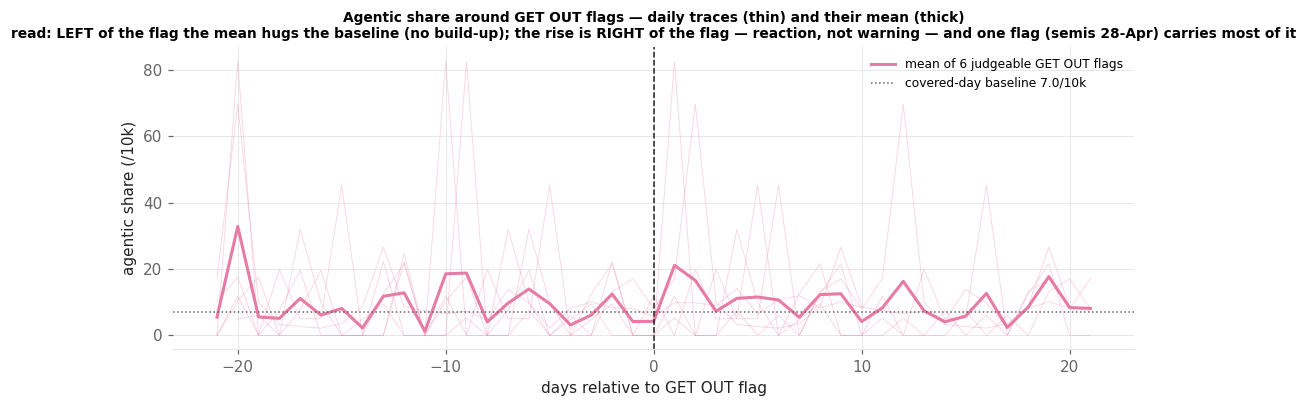

In [10]:
# the picture: daily relative-day traces around the judgeable GET OUT flags
fig, ax = plt.subplots(figsize=(9.5, 3.8))
rel = {}
for r in ev["GET OUT"].itertuples():
    w = df_all.loc[r.date - pd.Timedelta(days=EVENT_WIN):
                   r.date + pd.Timedelta(days=EVENT_WIN)]
    rd = (w.index - r.date).days
    rel[f"{r.name} {r.date.date()}"] = pd.Series(
        (w.hits / w.total * 1e4).values, index=rd)
rel = pd.DataFrame(rel)
ax.plot(rel.index, rel.mean(axis=1), color=C3, lw=2,
        label=f"mean of {rel.shape[1]} judgeable GET OUT flags")
for c in rel.columns:
    ax.plot(rel.index, rel[c], color=C3, lw=0.6, alpha=0.3)
base_rate = df_all.hits.sum() / df_all.total.sum() * 1e4
ax.axhline(base_rate, color=MUTED, ls=":", lw=1,
           label=f"covered-day baseline {base_rate:.1f}/10k")
ax.axvline(0, color=INK, ls="--", lw=1)
ax.set_xlabel("days relative to GET OUT flag")
ax.set_ylabel("agentic share (/10k)")
ax.set_title("Agentic share around GET OUT flags — daily traces (thin) and "
             "their mean (thick)\nread: LEFT of the flag the mean hugs the "
             "baseline (no build-up); the rise is RIGHT of the flag — "
             "reaction, not warning — and one flag (semis 28-Apr) carries "
             "most of it", fontsize=9)
ax.legend(frameon=False, fontsize=8)
despine(ax)
fig.tight_layout(); plt.show()

**SO WHAT — split the two questions the desk actually asked:**

* **Does the chatter LEAD the flag? NO.** Pre-flag share 7.6/10k vs the
  same-regime baseline 8.0/10k, CI spanning zero — there is no build-up
  in the three weeks before a GET OUT fires. That is the
  signal-relevant direction, and it is null.
* **Does it REACT to the flag? Weakly, maybe.** POST−PRE = +1.4 per 10k
  (5 of 6 flags up) and the naive 90% CI just excludes zero — but the
  leave-one-out shows fragility: 3 of the 6 single-flag deletions push
  the CI back over zero, and dropping the largest flag alone
  (semiconductors 28-Apr: +5.6) drops the mean to +0.6. Six events, one
  dominant — this is an anecdote with a confidence interval, recorded
  as "plausible reaction, no adoptable effect".
* **GET IN: NO EVIDENCE.** Zero judgeable flags — the 2026 GET INs fall
  in the thin Jan–Mar stretch or against the early-July archive gap.
  This is a coverage verdict, not a signal verdict, and it is the
  honest difference between "tested and null" and "untestable".

**IF ASKED — "the POST−PRE CI excludes zero; why is that not a
finding?"** Three reasons, each sufficient: (i) it is the wrong
direction for a signal — chatter rising *after* our flag helps nobody
trade; (ii) it fails leave-one-out — a result that one event can delete
is not a result under this project's own adoption standards (the same
reason NB04 refuses single-point maxima); (iii) six events give a
bootstrap CI its nominal coverage only under assumptions six events
cannot check. It is published, not adopted.

## §4b — Booms and busts: the 30 days into an episode peak

**HOW IT WORKS — and a trap this section deliberately leaves on
display.** The naive test compares pre-peak windows against ALL other
covered days. That baseline mixes regimes: it includes 2021's structural
zero and the near-zero Q1-2026 fringe, while every judgeable peak sits
in May–Jul 2026 when the whole series ran hotter. Any series that
merely GROWS over 2026 passes the naive test. The honest control is
same-regime ordinary days (≥ 2026-04-01, pre-peak windows removed) —
and computing it exposes the real problem: across a 40-name universe
the 30d pre-peak windows TILE the dense window almost completely, so
almost no control days exist at all.

In [11]:
peak_rows = []
for r in episodes.itertuples():
    w = df_all.loc[r.peak - pd.Timedelta(days=30):r.peak]
    if len(w) >= 15:                       # CONVENTION: ≥ half the window covered
        peak_rows.append({"name": r.name, "peak": r.peak.date(),
                          "pre_peak": w.hits.sum() / w.total.sum() * 1e4})
pk = pd.DataFrame(peak_rows)
pre_days = set()
for r in episodes.itertuples():
    pre_days |= set(df_all.loc[r.peak - pd.Timedelta(days=30):r.peak].index)
naive_ord = df_all.loc[~df_all.index.isin(pre_days)]
naive_rate = naive_ord.hits.sum() / naive_ord.total.sum() * 1e4
dense_ord = df_all.loc["2026-04-01":]
dense_ord = dense_ord.loc[~dense_ord.index.isin(pre_days)]
dense_rate = dense_ord.hits.sum() / dense_ord.total.sum() * 1e4
print(pk.round(2).to_string(index=False))
print(f"\n{len(pk)} episode peaks with ≥15 covered pre-peak days "
      f"(several share dates — e.g. solar/ev_clean_energy — so these are "
      "not independent draws)")
nlo, nhi = boot_ci(pk["pre_peak"].values - naive_rate)
dlo, dhi = boot_ci(pk["pre_peak"].values - dense_rate)
n_dense_all = len(df_all.loc["2026-04-01":])
print(f"NAIVE   : pre-peak {pk.pre_peak.mean():.2f}/10k vs {naive_rate:.2f} "
      f"on all other covered days | gap CI90 [{nlo:+.2f}, {nhi:+.2f}] — "
      "looks 'significant', and is WRONG: the baseline mixes regimes "
      "(it contains 2021's structural zero and the near-zero Q1 fringe)")
print(f"CONTROL : same-regime ordinary days left after removing pre-peak "
      f"windows: {len(dense_ord)} of {n_dense_all} dense days — all from "
      f"one mid-July fortnight (rate {dense_rate:.2f}, gap CI90 "
      f"[{dlo:+.2f}, {dhi:+.2f}])")
print("VERDICT : DEGENERATE - with ~40 tracked names, 30d pre-peak windows "
      "tile the whole dense window; no genuine control group exists on "
      "this history, so 'pre-peak vs ordinary' cannot be answered yet")

           name       peak  pre_peak
           SNAP 2026-05-01      5.25
uranium_nuclear 2026-05-06      5.53
ev_clean_energy 2026-05-11      6.05
          solar 2026-05-11      6.05
           WKHS 2026-05-28      8.39
           SPCE 2026-06-01     11.01
     cloud_saas 2026-06-01     11.01
            NOK 2026-06-02     10.20
            AMC 2026-06-18      8.37
         memory 2026-06-22      8.58
 semiconductors 2026-06-22      8.58
             BB 2026-07-01      8.57

12 episode peaks with ≥15 covered pre-peak days (several share dates — e.g. solar/ev_clean_energy — so these are not independent draws)
NAIVE   : pre-peak 8.13/10k vs 5.48 on all other covered days | gap CI90 [+1.75, +3.58] — looks 'significant', and is WRONG: the baseline mixes regimes (it contains 2021's structural zero and the near-zero Q1 fringe)
CONTROL : same-regime ordinary days left after removing pre-peak windows: 14 of 98 dense days — all from one mid-July fortnight (rate 6.70, gap CI90 [+0.49, +2.36])


**SO WHAT** — **the boom test is UNTESTABLE on this history, and both
ways of pretending otherwise are shown failing.** The naive comparison
(+2.7/10k, CI excluding zero) is the series' own 2026 growth
masquerading as a boom signature; the same-regime comparison leaves 14
control days, all from a single July fortnight, so its CI measures
May-June-vs-July, not boom-vs-calm. What CAN be said: within the dense
window the pre-peak share (~8.1/10k) sits in the same band as every
§4a/§4c reading — nothing suggests concentration in booms, and nothing
could yet prove it either way.

**IF ASKED — "why print the naive version at all?"** Because it is the
version a quick script would produce, and it looks significant. Leaving
it next to the degenerate control, with the reason each fails, is
cheaper than re-litigating it later.

## §4c — Lead/lag vs the aggregate euphoria level

**HOW IT WORKS** — the aggregate euphoria level is the mean of the 0–100
per-name levels across the tracked universe (the dashboard's market
gauge). Cross-correlation of the daily agentic share with that level at
lags −21..+21d, on the dense contiguous island only (Apr–Jul 2026), in
LEVELS and in 7d CHANGES (both series trend upward over a 4-month
window, and two upward trends correlate at every lag — the changes row
is the guard against exactly that artefact). CIs by moving-block
bootstrap (block = 7 days, **CONVENTION**: the project's house week,
long enough to hold the visible autocorrelation).

6s | 84 overlapping days | lags whose 90% CI excludes zero: levels 0/43, 7d-changes 7/43 (~4.3 expected by chance at 90%)
the 7d-change lags that clear the CI (read the SIGNS - they alternate, which is what chance looks like, not a lead):
 lag  r_diff7  lo_diff7  hi_diff7
   4    0.163     0.010     0.295
   7    0.234     0.057     0.387
  14   -0.238    -0.431    -0.037
  15   -0.229    -0.378    -0.054
  16   -0.222    -0.383    -0.052
  17   -0.276    -0.466    -0.123
  21    0.166     0.015     0.387


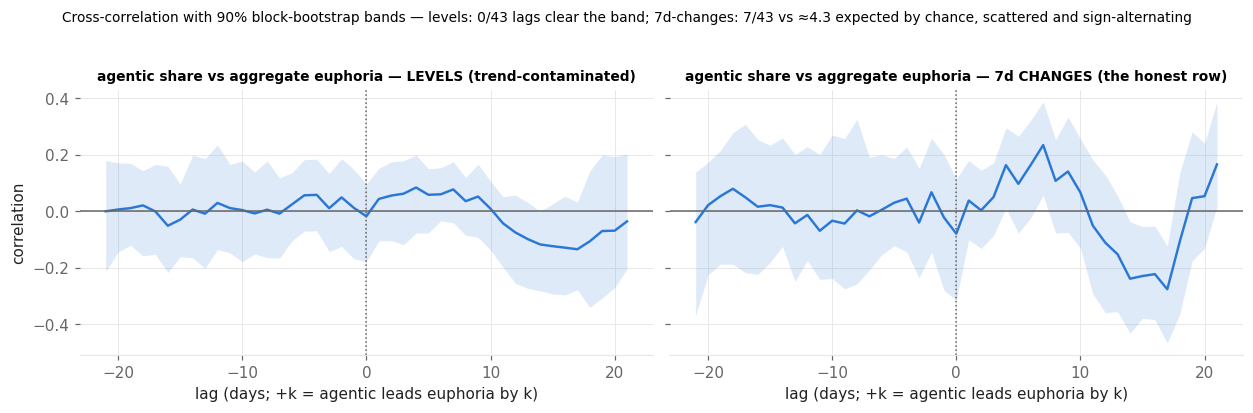

In [12]:
agg_level = levels.groupby("date")["level"].mean()
dense = df_all.loc["2026-04-01":]
dense = dense[~dense.index.to_series().diff().dt.days.gt(3).cummax()] \
    if dense.index.to_series().diff().dt.days.gt(3).any() else dense
share = (dense.hits / dense.total * 1e4)
lvl = agg_level.reindex(share.index)
LAGS = range(-EVENT_WIN, EVENT_WIN + 1)

def block_boot_corr(x, y, lag, n_boot=1000, block=7):
    """corr(x_t, y_{t+lag}) with a moving-block bootstrap CI."""
    a = x.copy(); b = y.shift(-lag)
    ok = a.notna() & b.notna()
    a, b = a[ok].values, b[ok].values
    n = len(a)
    if n < 30:
        return np.nan, (np.nan, np.nan), n
    r = np.corrcoef(a, b)[0, 1]
    starts = np.arange(n - block + 1)
    reps = []
    for _ in range(n_boot):
        idx = np.concatenate([np.arange(s, s + block) for s in
                              rng.choice(starts, n // block + 1)])[:n]
        reps.append(np.corrcoef(a[idx], b[idx])[0, 1])
    return r, tuple(np.percentile(reps, (5, 95))), n

t0 = time.time()
xc_rows = []
for lag in LAGS:
    rL, ciL, nL = block_boot_corr(share, lvl, lag)
    rD, ciD, nD = block_boot_corr(share.diff(7), lvl.diff(7), lag)
    xc_rows.append({"lag": lag, "r_level": rL, "lo_level": ciL[0],
                    "hi_level": ciL[1], "r_diff7": rD, "lo_diff7": ciD[0],
                    "hi_diff7": ciD[1], "n": nL})
xc = pd.DataFrame(xc_rows)
n_sig_lvl = int(((xc.lo_level > 0) | (xc.hi_level < 0)).sum())
sig_dif = xc[(xc.lo_diff7 > 0) | (xc.hi_diff7 < 0)]
n_sig_dif = int(len(sig_dif))
print(f"{time.time()-t0:.0f}s | {xc.n.iloc[EVENT_WIN]} overlapping days | "
      f"lags whose 90% CI excludes zero: levels {n_sig_lvl}/43, "
      f"7d-changes {n_sig_dif}/43 (~{43 * 0.10:.1f} expected by chance "
      "at 90%)")
if n_sig_dif:
    print("the 7d-change lags that clear the CI (read the SIGNS - they "
          "alternate, which is what chance looks like, not a lead):")
    print(sig_dif[["lag", "r_diff7", "lo_diff7", "hi_diff7"]]
          .round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=True)
for ax_, (rcol, locol, hicol, ttl) in zip(axes, [
        ("r_level", "lo_level", "hi_level", "LEVELS (trend-contaminated)"),
        ("r_diff7", "lo_diff7", "hi_diff7", "7d CHANGES (the honest row)")]):
    ax_.fill_between(xc.lag, xc[locol], xc[hicol], color=C1, alpha=0.15,
                     lw=0)
    ax_.plot(xc.lag, xc[rcol], color=C1, lw=1.6)
    ax_.axhline(0, color=MUTED, lw=1)
    ax_.axvline(0, color=MUTED, ls=":", lw=1)
    ax_.set_title(f"agentic share vs aggregate euphoria — {ttl}",
                  fontsize=9)
    ax_.set_xlabel("lag (days; +k = agentic leads euphoria by k)")
    despine(ax_)
axes[0].set_ylabel("correlation")
fig.suptitle(f"Cross-correlation with 90% block-bootstrap bands — levels: "
             f"{n_sig_lvl}/43 lags clear the band; 7d-changes: "
             f"{n_sig_dif}/43 vs ≈4.3 expected by chance, scattered and "
             "sign-alternating", fontsize=9, y=1.03)
fig.tight_layout(); plt.show()

In [13]:
# variant check: does any variant (ask_ai only / excl-ai themes) differ?
var_peaks = {}
for label, dfv in VARIANTS.items():
    dv = dfv.loc[share.index]
    sv = dv.hits / dv.total * 1e4
    best_lag, best_r = 0, 0.0
    for lag in LAGS:
        b = lvl.shift(-lag)
        ok = sv.notna() & b.notna()
        if ok.sum() >= 30:
            r = np.corrcoef(sv[ok], b[ok])[0, 1]
            if abs(r) > abs(best_r):
                best_lag, best_r = lag, r
    var_peaks[label] = {"best_lag": best_lag, "best_r": round(best_r, 3)}
print("largest |r| across lags, per variant (levels):")
for k, v in var_peaks.items():
    print(f"  {k:28s} lag {v['best_lag']:+3d}  r={v['best_r']:+.3f}")
print("every variant's best |r| stays below 0.15, at inconsistent lags "
      "and signs - excluding the ai/ai_megacap theme attribution changes "
      "nothing, so the (null) answer is not an artefact of the AI theme's "
      "own chatter (nor rescued by removing it)")

largest |r| across lags, per variant (levels):
  all categories               lag +17  r=-0.134
  ask_ai only                  lag  +4  r=+0.114
  all, excl theme=ai           lag +15  r=-0.130
  all, excl ai + ai_megacap    lag +17  r=-0.114
every variant's best |r| stays below 0.15, at inconsistent lags and signs - excluding the ai/ai_megacap theme attribution changes nothing, so the (null) answer is not an artefact of the AI theme's own chatter (nor rescued by removing it)


**SO WHAT**

* **NULL.** In levels no lag clears its CI; in 7d changes 7 of 43 do —
  about what ~43 tests at 90% produce by luck (≈4.3 expected), at
  scattered lags with alternating signs (+7d positive, +14d negative is
  not a lead structure, it is noise). Best |r| anywhere ≈ 0.28 on 84
  days.
* The contamination guard mattered in design even though it did not
  change the answer: had a correlation appeared ONLY with the `ai` theme
  included, it would have been the keyword list talking to itself.

**IF ASKED — "could a real link hide under 4 months of data?"** Easily —
that is the stated limitation, not a defence of the null. A daily effect
smaller than ~0.3 correlation, or one that only operates in manias
(2026's window contains exactly one macro regime), is invisible at this
sample size. The re-test condition is written in §5.

---
# §5 — What ships, what does not, and one line for the PM

**WHAT SHIPS**

* The **measurement**: the daily agentic store, the term-bank CSV, and
  the dashboard page (series + LLM digest when the gateway is present).
  It ships as *measurement + digest* — a thing the desk watches, like
  the mood gauge.

**WHAT DOES NOT SHIP, and the pre-stated bar for changing that**

* Nothing from this store enters the signal layer, the feature banks or
  the candidacy gates. Every link test is null or untestable on ~4 dense
  months.
* The bar (recorded now so it cannot drift): agentic share may be
  proposed as a feature only after (i) ≥2 years of dense archive
  coverage, (ii) the §4 event study shows a PRE-flag effect whose 90%
  CI excludes zero, and (iii) it survives the project's standard
  walk-forward protocol (notebook 03's tournament rules) inside the FA
  budget. Anything less is curve-fitting a 6-event anecdote.

**LIMITATIONS, plainly**

* Coverage is the story: two days of 2021, thin Q1-2026, four dense
  months. Every §4 number is hostage to that.
* Counts are small (tens/day): daily rates are noisy by construction,
  so anything sub-weekly is over-reading.
* The term bank is English-language and entity-list based (ChatGPT,
  Claude, Gemini, Grok, Copilot, DeepSeek — new tools need a CSV row).
* ask_ai includes some non-trading AI conversation (measured honestly in
  §3); the store counts "AI in the financial conversation", not verified
  trade intent.

**One line for the PM:** *about 1 post in 1,200 now involves an AI in
the trade — mostly "ChatGPT/Grok told me X" — and on the four dense
months we can test, that chatter neither leads our flags nor thickens
before booms and busts; the counter runs daily, the digest ships, the
signal claim waits for history.*

In [14]:
out = {
    "as_of": pd.Timestamp.now().isoformat(timespec="seconds"),
    "store": {
        "rows": int(len(ag)),
        "archive_days": int(len(tot)),
        "covered_days": int(len(covered)),
        "min_day_posts": MIN_DAY_POSTS,
        "coverage_islands": [[str(lo.date()), str(hi.date())]
                             for lo, hi in runs],
        "hits_by_category": {k: int(v) for k, v in hits_all.groupby(
            "category")["mention_count"].sum().items()},
        "pooled_share_per_10k": {
            k: float(v.hits.sum() / v.total.sum() * 1e4)
            for k, v in VARIANTS.items()},
        "structural_zero_2021": {
            "days": 2, "posts": int(tot.loc["2021"].sum()), "hits": 0},
    },
    "event_study": {
        side: ({
            "judgeable_flags": int(len(tbl)),
            "flags": [{"date": str(r.date.date()), "name": r.name,
                       "pre": float(r.pre), "post": float(r.post)}
                      for r in tbl.itertuples()],
            "post_minus_pre_mean": float(tbl["delta"].mean()),
            "post_minus_pre_ci90": list(boot_ci(tbl["delta"].values)),
            "pre_vs_baseline_ci90": list(
                boot_ci(tbl["pre"].values
                        - df_all.loc["2026-04-01":].hits.sum()
                        / df_all.loc["2026-04-01":].total.sum() * 1e4)),
            "verdict": "NO LEAD (pre-flag CI spans zero); post-flag rise "
                       "fails leave-one-out - published, not adopted",
        } if len(tbl) else {
            "judgeable_flags": 0,
            "verdict": "UNTESTABLE - no judgeable flags",
        }) for side, tbl in ev.items()},
    "episode_prepeak": {
        "n_peaks": int(len(pk)),
        "mean_prepeak_share": float(pk.pre_peak.mean()),
        "naive_ordinary_share": float(naive_rate),
        "naive_gap_ci90": [float(nlo), float(nhi)],
        "same_regime_control_days": int(len(dense_ord)),
        "same_regime_share": float(dense_rate),
        "same_regime_gap_ci90": [float(dlo), float(dhi)],
        "verdict": "DEGENERATE - pre-peak windows tile the dense window; "
                   "no genuine control group exists on this history",
    },
    "leadlag": {
        "n_days": int(xc.n.iloc[EVENT_WIN]),
        "lags_ci_excl_zero_levels": n_sig_lvl,
        "lags_ci_excl_zero_diff7": n_sig_dif,
        "chance_expectation": 4.3,
        "max_abs_r_by_variant": var_peaks,
        "verdict": "NULL - consistent with chance at every lag, "
                   "every variant",
    },
    "llm_digest": ("written" if ai.available() else
                   "PENDING - desk machine (Apollo gateway)"),
    "ships": "measurement + digest only; signal-layer use gated on >=2y "
             "dense coverage + walk-forward protocol",
}
with open(RESEARCH_DIR / "nb09_agentic_watch.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print(f"saved nb09_agentic_watch.json | total runtime "
      f"{time.time()-NB_T0:.0f}s")

saved nb09_agentic_watch.json | total runtime 7s
